### Exploration and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/Telco_Churn_Dataset.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* we can cleary see that the data has no null values to fill
* MonthlyCharges and TotalCharges are different in data type; therefore, we need to convert to numeric data type for analysis
* CustomerID has no significance in further modeling of the data, hence dropped

In [7]:
df = df.drop('customerID', axis=1)

* High Monthly charges has higher chances of Churn and it's free from gender bias
* Tenure has likely less to do with Churn
* At lower term contracts we can see higher avergae monthly charges

In [8]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


#### EDA and Data Preprocessing

In [9]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [10]:
df.groupby(['Churn','gender'])['MonthlyCharges'].mean()

Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64

In [11]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [12]:
df.groupby(['Contract','Churn'])['MonthlyCharges'].mean()

Contract        Churn
Month-to-month  No       61.462635
                Yes      73.019396
One year        No       62.508148
                Yes      85.050904
Two year        No       60.012477
                Yes      86.777083
Name: MonthlyCharges, dtype: float64

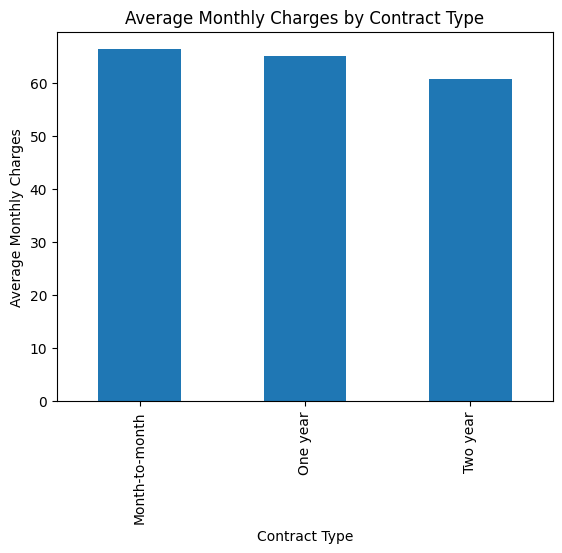

In [13]:
df.groupby(['Contract'])['MonthlyCharges'].mean().plot(kind='bar')
plt.xlabel('Contract Type')
plt.ylabel('Average Monthly Charges')
plt.title('Average Monthly Charges by Contract Type')
plt.show()

* We can clearly see below, that after conversion to numeric datatype, TotalCharges have total of 11 null cols, since the number is relative small we can mean impute it

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

cols = ['MonthlyCharges', 'TotalCharges']
df[cols].isnull().sum()

MonthlyCharges     0
TotalCharges      11
dtype: int64

* We can infer from this dataset is that, people who purchased the service did not complete a month; which marks their tenure as 0, hence the total charges becomes 0 ( assuming formula to be: TotalCharges = Tenure * MonthlyCharges )

In [15]:
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


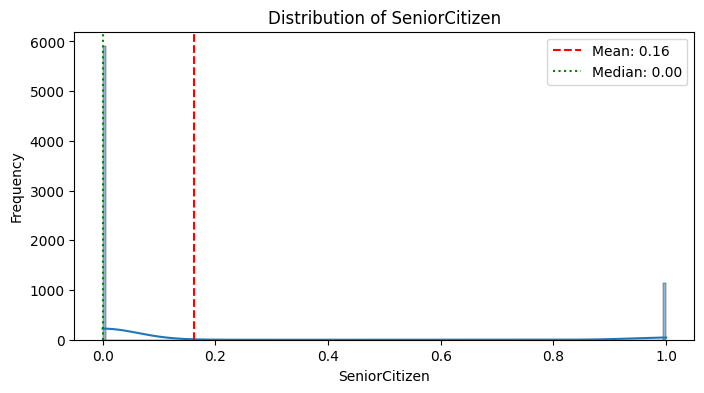

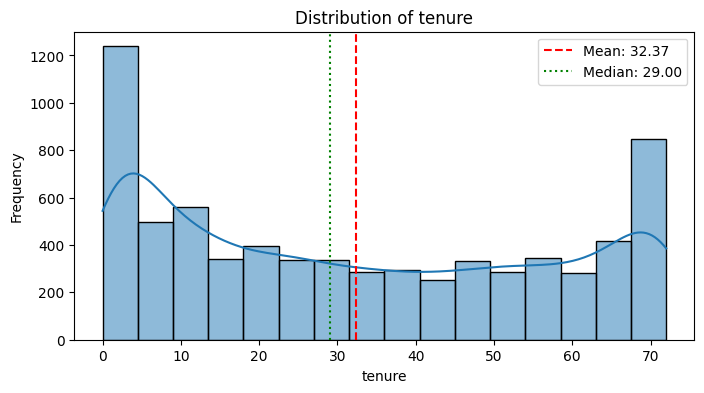

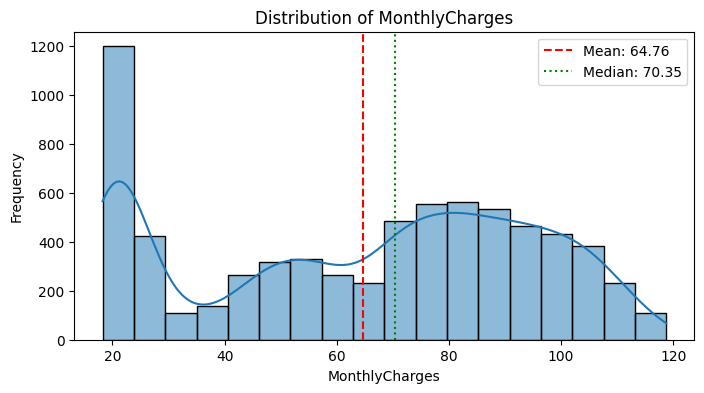

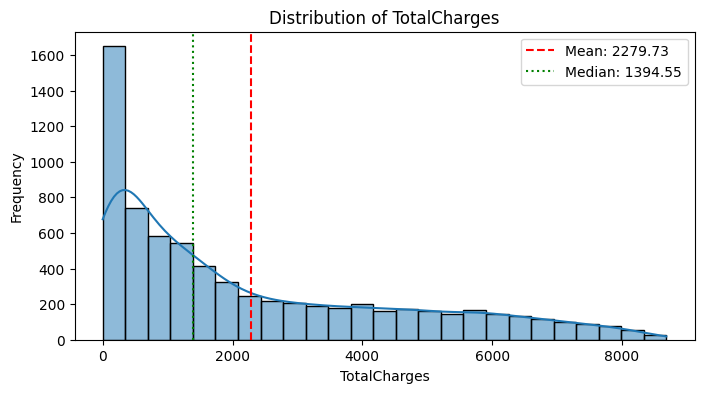

In [19]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    col_mean = df[col].mean()
    col_median = df[col].median()

    plt.axvline(col_mean, color='red', linestyle='--', label=f'Mean: {col_mean:.2f}')
    plt.axvline(col_median, color='green', linestyle=':', label=f'Median: {col_median:.2f}')
    plt.legend()
    plt.show()

* The 'TotalCharges' distribution appears to be right skewed, with a mean higher than the median, i.e. that there are customers with very high total charges, likely because of longer tenure or higher monthly charges
* It can also be noted that, the distribution of each numerical feature is not uniform or normally distributed which makes it non applicable to models like regression or svm.
* So, we can either perform standard feature scaling or we can just use Decision Trees as they are less sensitive to such distributions.

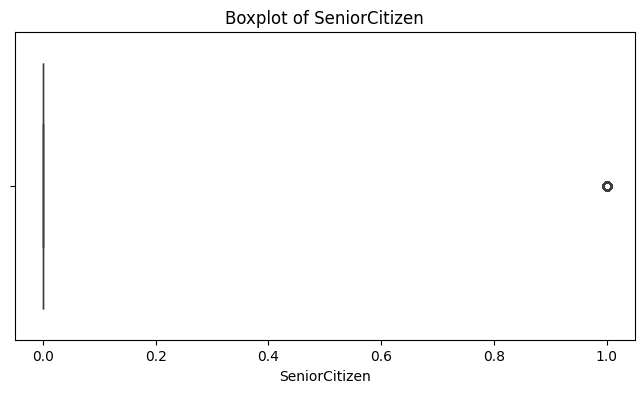

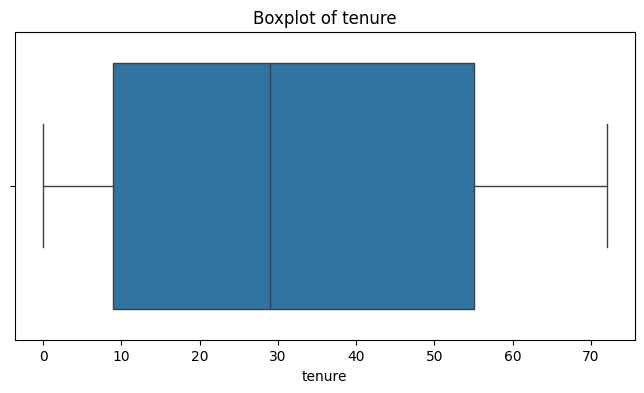

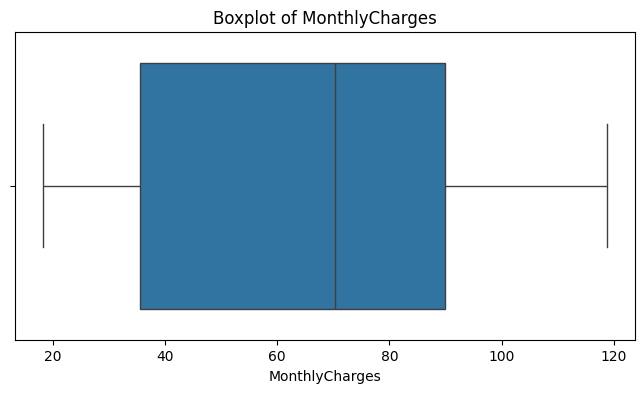

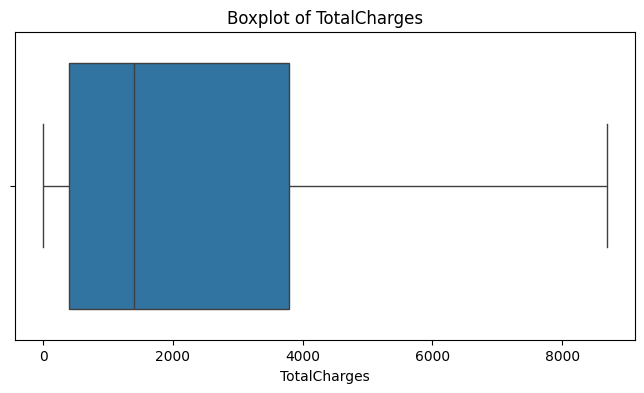

In [20]:
for cols in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[cols])
    plt.title(f'Boxplot of {cols}')
    plt.xlabel(cols)
    plt.show()

* Also, No outliers can be found in the data

#### Feature Engineering

In [24]:
for col in df.select_dtypes(include=['object']).columns:
    print(f'{col} value counts:')
    print(df[col].value_counts())
    print('\n')

gender value counts:
gender
Male      3555
Female    3488
Name: count, dtype: int64


Partner value counts:
Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents value counts:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


PhoneService value counts:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64


MultipleLines value counts:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService value counts:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity value counts:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


OnlineBackup value counts:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


DeviceProtection value counts:
DeviceProtection
No               

In [25]:
binary_cols =[
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})
df.head(5)

C:\Users\serve\AppData\Local\Temp\ipykernel_17084\419692713.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [26]:
multi_cat_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'DeviceProtection',
    'OnlineBackup',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
df.head(5)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [27]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


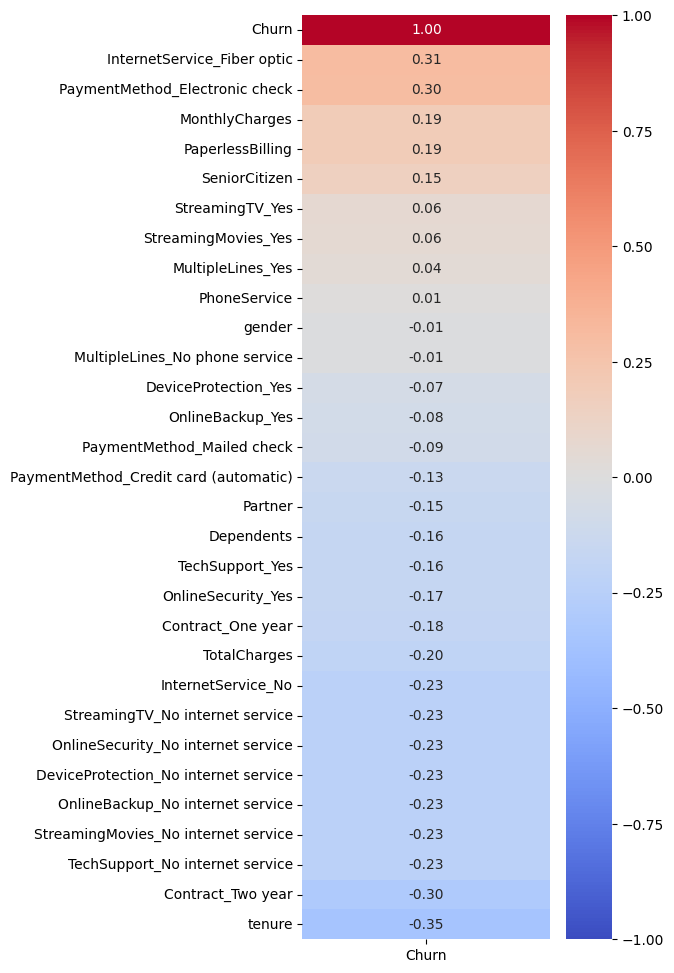

In [28]:
import matplotlib.pyplot as plt
corr_mat = df.corr(numeric_only=True)
churn_corr = corr_mat[['Churn']].sort_values(by='Churn',ascending=False)
plt.figure(figsize=(4,12))
sns.heatmap(churn_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

* It can be inferred that 'MonthlyCharges' has the highest positive correlation with 'Churn' among numerical features, suggesting customers with higher bills are more likely to churn. Separately, the categorical correlation shows that month-to-month contracts are heavily associated with churn.

In [29]:
# We need to collapse redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [30]:
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

e:\Vedarham\Practice FAILURE\Telco_Churn_Model\.venv-1\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1770.644580
7                          MonthlyCharges   865.062147
10            InternetService_Fiber optic   148.263380
24                       No_phone_service    60.867536
17                    StreamingMovies_Yes    24.110253
16                        StreamingTV_Yes    24.056827
8                            TotalCharges    10.793729
4                                  tenure     7.527280
9                       MultipleLines_Yes     7.273906
13                   DeviceProtection_Yes     6.922434
14                       OnlineBackup_Yes     6.782866
15                        TechSupport_Yes     6.467893
12                     OnlineSecurity_Yes     6.336249
19                      Contract_Two year     2.632246
21         PaymentMethod_Electronic check     1.976144
22        

* VIF values above 5 indicate potential multicollinearity issues. 
* In this case, 'TotalCharges' has a VIF of 10.8, which suggests it is highly correlated with other features, likely 'tenure' and 'MonthlyCharges'.
* We may consider dropping 'TotalCharges' to reduce multicollinearity in our model
* Which is maybe considering using regularization techniques like Lasso or Ridge regression to handle this
* We may also use Decision Tree, as they are less sensitive to multicollinearity, which is based on reducing impurities in later splits and alone on importance of the feature.

In [32]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

We have a class imbalance problem, with 5174 non-churners and 1869 churners. 
* This may require techniques such as resampling or using algorithms that can handle imbalanced data to ensure that our model does not become biased towards the majority class.
* such algorithms include Random Forest, Gradient Boosting, or XGBoost, which can handle imbalanced datasets effectively. 
* Additionally, we could consider using techniques like SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class (churners) to balance the dataset before training our model.

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

#### SMOTE

In [35]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [36]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [37]:
y_train_smote.value_counts()

Churn
0    4139
1    4139
Name: count, dtype: int64

#### Model Training and Evaluation


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

In [39]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None,10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
}

param_grid_lgbm = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'num_leaves': [31, 50, 70],
    'subsample': [0.5, 0.7, 1.0],
}

In [40]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_spaces = {
    "Decision Tree": param_grid_dt,
    "Random Forest": param_grid_rf,
    "XGBoost": param_grid_xgb,
    "LightGBM": param_grid_lgbm,
}

best_estimators = {}

for name, model in models.items():
    print(f"\n{name} cross-validation")
    auc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='f1', n_jobs=-1)
    acc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"  ROC AUC: mean={auc_scores.mean():.4f}, std={auc_scores.std():.4f}")
    print(f"  F1:      mean={f1_scores.mean():.4f}, std={f1_scores.std():.4f}")
    print(f"  Accuracy: mean={acc_scores.mean():.4f}, std={acc_scores.std():.4f}")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_spaces[name],
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )
    search.fit(X_train_smote, y_train_smote)

    best_estimators[name] = search.best_estimator_
    print(f"  Best ROC AUC (cv): {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

thresholds = [i / 10 for i in range(1, 10)]
for name, model in best_estimators.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)
        probs = 1 / (1 + np.exp(-probs))

    print(f"\n{name} tuned model threshold results")
    for th in thresholds:
        preds = (probs >= th).astype(int)
        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        print(f" threshold={th:.2f} | accuracy={acc:.3f} | precision={prec:.3f} | recall={rec:.3f} | f1={f1:.3f}")


Decision Tree cross-validation
  ROC AUC: mean=0.7931, std=0.0093
  F1:      mean=0.7945, std=0.0073
  Accuracy: mean=0.7925, std=0.0092
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best ROC AUC (cv): 0.8735
  Best params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'entropy'}

Random Forest cross-validation
  ROC AUC: mean=0.9234, std=0.0041
  F1:      mean=0.8458, std=0.0066
  Accuracy: mean=0.8451, std=0.0068
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best ROC AUC (cv): 0.9254
  Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'bootstrap': False}

XGBoost cross-validation
  ROC AUC: mean=0.9263, std=0.0025
  F1:      mean=0.8448, std=0.0051
  Accuracy: mean=0.8433, std=0.0047
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best ROC AUC (cv): 0.9273
  Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'c

#### Random Forest gives highest AUC and F1 scores, so we will select it as our final model.

In [41]:
xgb = best_estimators["XGBoost"]

model = xgb.fit(X_train_smote, y_train_smote)

In [42]:
y_test.value_counts()

Churn
0    1035
1     374
Name: count, dtype: int64

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"classification report: \n{classification_report(y_test, y_pred)}")


Confusion Matrix: 
[[862 173]
 [147 227]]
Test Accuracy: 0.7729
Test Precision: 0.5675
Test Recall: 0.6070
Test F1 Score: 0.5866
Test ROC AUC: 0.8146
classification report: 
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.57      0.61      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409

